In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
fdata = "API_FP.CPI.TOTL.ZG_DS2_en_csv_v2_4522.csv"
df = pd.read_csv(fdata, skiprows=4)
df.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,NaN,NaN,NaN,NaN,NaN,NaN,...,-1.028282,3.626041,4.257462,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Africa Eastern and Southern,AFE,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,NaN,NaN,NaN,NaN,NaN,NaN,...,6.221375,4.689806,4.102851,5.191629,6.824727,10.883478,7.399186,4.770857,4.270111,NaN
2,Afghanistan,AFG,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,NaN,NaN,NaN,NaN,NaN,NaN,...,4.975952,0.626149,2.302373,5.601888,5.133203,13.712102,-4.644709,-6.601186,NaN,NaN
3,Africa Western and Central,AFW,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,NaN,NaN,NaN,NaN,NaN,NaN,...,1.725486,1.784050,1.983092,2.490378,3.745568,7.949251,5.221168,3.608044,1.657818,NaN
4,Angola,AGO,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,NaN,NaN,NaN,NaN,NaN,NaN,...,29.844480,19.628938,17.080954,22.271539,25.754295,21.355290,13.644102,28.240495,20.162020,NaN


In [3]:
countries = ["Lebanon", "Jordan", "Egypt, Arab Rep.", "Tunisia", "Morocco", "Turkiye", "Iraq"]
df_filtered = df[df['Country Name'].isin(countries)]
df_filtered

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
67,"Egypt, Arab Rep.",EGY,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,0.332829,0.693607,-3.003077,0.746646,3.660983,14.839004,...,29.506608,14.401466,9.152800,5.044933,5.214049,13.895661,33.884776,28.270590,14.073514,NaN
112,Iraq,IRQ,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,3.478238,0.916260,1.292362,3.954957,-0.090137,-0.455581,...,0.184059,0.367441,-0.198965,0.574163,6.041865,4.994766,4.358354,2.611696,0.303455,NaN
117,Jordan,JOR,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,NaN,NaN,NaN,NaN,NaN,NaN,...,3.323894,4.462311,0.761514,0.333294,1.346094,4.229156,2.084870,1.556596,1.766465,NaN
129,Lebanon,LBN,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,NaN,NaN,NaN,NaN,NaN,NaN,...,4.321352,6.076989,3.005389,84.864333,154.756096,171.205491,221.341644,45.243042,14.597596,NaN
147,Morocco,MAR,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,3.424299,1.763125,5.096729,5.699712,4.021541,3.482821,...,0.754663,1.803917,0.303386,0.705969,1.401959,6.657042,6.091142,0.985257,0.701902,NaN
242,Tunisia,TUN,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,NaN,NaN,NaN,NaN,NaN,NaN,...,5.308848,7.307592,6.720075,5.634151,5.706350,8.306461,9.328996,7.206617,5.151002,NaN
243,Turkiye,TUR,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,5.664740,3.172857,3.888320,6.362707,1.119638,4.555534,...,11.144311,16.332464,15.176822,12.278957,19.596493,72.308836,53.859409,58.506451,34.881163,NaN


In [4]:
df_long = df_filtered.melt(
    id_vars=['Country Name', 'Country Code'],
    value_vars=[str(y) for y in range(2015, 2025)],
    var_name='Year',
    value_name='Inflation'
)
df_long['Year'] = df_long['Year'].astype(int)
df_long

,Country Name,Country Code,Year,Inflation
0,"Egypt, Arab Rep.",EGY,2015,10.370490
1,Iraq,IRQ,2015,1.393330
2,Jordan,JOR,2015,-0.876851
3,Lebanon,LBN,2015,-3.749145
4,Morocco,MAR,2015,1.557907
...,...,...,...,...
65,Jordan,JOR,2024,1.556596
66,Lebanon,LBN,2024,45.243042
67,Morocco,MAR,2024,0.985257
68,Tunisia,TUN,2024,7.206617


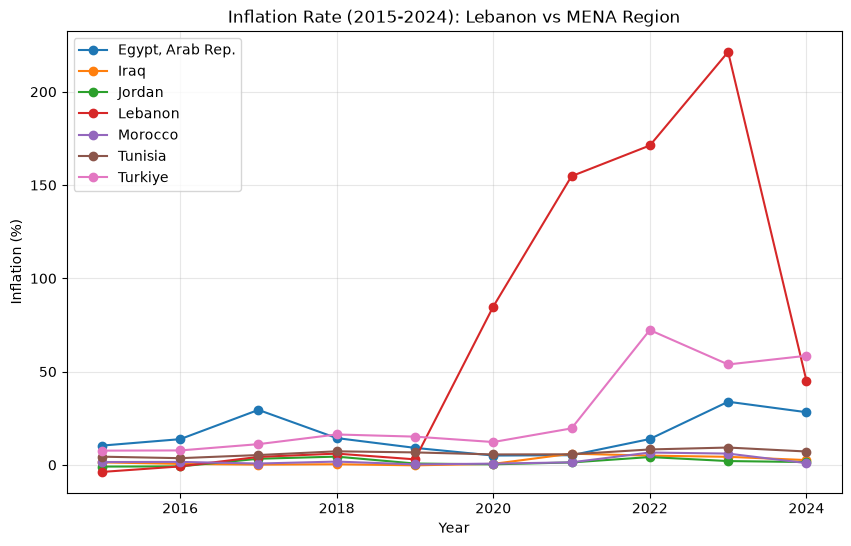

In [5]:
plt.figure(figsize=(10,6))
for country in df_long['Country Name'].unique():
    subset = df_long[df_long['Country Name'] == country]
    plt.plot(subset['Year'], subset['Inflation'], marker='o', label=country)

plt.title('Inflation Rate (2015-2024): Lebanon vs MENA Region')
plt.xlabel('Year')
plt.ylabel('Inflation (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

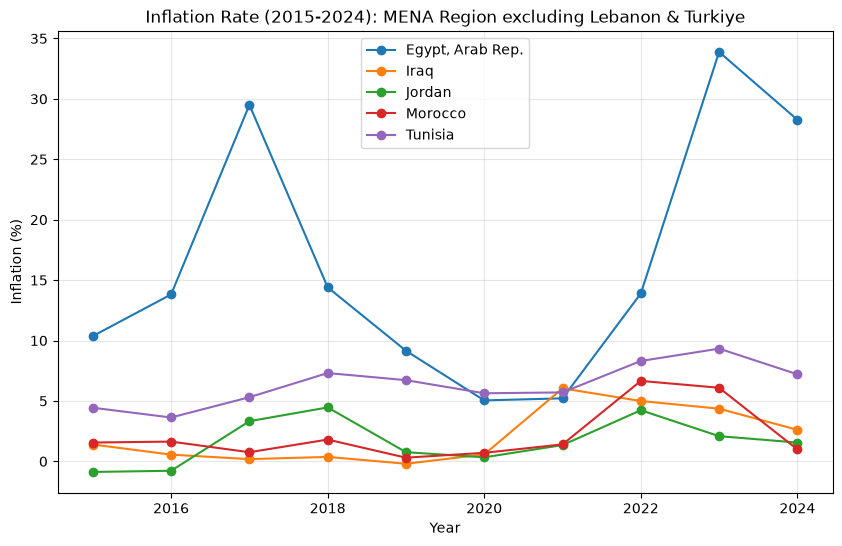

In [6]:
excluded = ["Lebanon", "Turkiye"]
df_zoomed = df_long[~df_long['Country Name'].isin(excluded)]

plt.figure(figsize=(10,6))
for country in df_zoomed['Country Name'].unique():
    subset = df_zoomed[df_zoomed['Country Name'] == country]
    plt.plot(subset['Year'], subset['Inflation'], marker='o', label=country)

plt.title('Inflation Rate (2015-2024): MENA Region excluding Lebanon & Turkiye')
plt.xlabel('Year')
plt.ylabel('Inflation (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Lebanon inflation crisis began with the 2019 economic collapse and worsened through the covid-19 pandemic. Moreover, it peaked at 221% in 2023 before decreasing to 45% in 2024. This is higher than every country in the MENA Region. As an example, Turkey which known for high inflation peaked at 72% at the same time, while the region stayed under 20%.Excluding Lebanon and Türkiye, the remaining countries show their own independent patterns. Like Egypt experienced two distinct inflation spikes (2017 and 2023), likely tied to currency devaluations, suggesting the crisis in Lebanon was not simply a regional trend but a country specific collapse. the human impact was sever: purchasing power collapsed, and much of the middle class was pushed into poverty as wages failed to keep pace with prices. It's worth noting that inflation alone doesn't capture the full crisis, the banking sector freeze on withdrawals and a sharp GPD free fall  contraction compounded the damage. Would be worth examining in a follow-up analysis.
